# Cats-in-Pain Dataset v2 — Analysis

This notebook loads **`final_dataset_v2.jsonl`** (merged from static detection, GPT-4o descriptions, cat identity clustering, and separated-audio emotion labels) and summarizes **coverage, label quality, GPT metadata, and training suitability**.

Sections: dataset overview, label distributions, GPT description analysis, cat-identity / clusters, training-set summary, and audio–visual agreement.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid")


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(12):
        cfg = p / "dataset_construction" / "config.yaml"
        if cfg.is_file():
            return p
        p = p.parent
    raise FileNotFoundError("Could not find dataset_construction/config.yaml (walk parents from cwd).")


REPO_ROOT = find_repo_root()
CONFIG_PATH = REPO_ROOT / "dataset_construction" / "config.yaml"
with open(CONFIG_PATH, encoding="utf-8") as f:
    _cfg = yaml.safe_load(f)
_fd = _cfg.get("final_dataset") or {}
CONF_THR = float(_fd.get("confidence_threshold", 0.65))
MARGIN_THR = float(_fd.get("margin_threshold", 0.15))
LABEL_10_TO_5 = dict(_fd.get("label_map_10_to_5") or {})

MANIFEST = REPO_ROOT / _fd["output_manifest"]
rows = []
with open(MANIFEST, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
print(f"Loaded {len(df)} snippets")

prob_cols = [c for c in df.columns if c.startswith("prob_")]
df["_margin"] = df[prob_cols].apply(
    lambda r: float(np.sort(r.values)[-1] - np.sort(r.values)[-2]) if r.notna().sum() >= 2 else np.nan,
    axis=1,
)

_key_cols = [
    "snippet_id", "platform", "final_label_5", "audio_confidence",
    "suitable_for_training", "duration_sec",
]
print(df[[c for c in _key_cols if c in df.columns]].dtypes)

COLORS_5 = {
    "Paining": "#e41a1c",
    "Positive_Baseline": "#4daf4a",
    "Agonistic": "#ff7f00",
    "Vocalizing": "#984ea3",
    "HuntingMind": "#4682b4",
}
COLORS_BINARY = {"Pain": "#e41a1c", "No_Pain": "#4682b4"}


Loaded 7318 snippets
snippet_id                object
platform                  object
final_label_5             object
audio_confidence         float64
suitable_for_training       bool
duration_sec             float64
dtype: object


## 1. Dataset Overview


In [2]:
plat_counts = df["platform"].fillna("unknown").value_counts()
n_vid = df["video_id"].nunique()
n_cat = df["cat_id"].nunique()
hours = df["duration_sec"].sum() / 3600.0
suit = int(df["suitable_for_training"].sum())
hi = int((df["label_source"] == "audio_high_conf").sum())

print(f"Total snippets:           {len(df)}")
print(f"Unique videos:            {n_vid}")
print(f"Unique cat_ids:           {n_cat}")
print(f"Approx. hours of video:   {hours:.1f}h")
print(
    "Platforms: "
    + " | ".join(f"{p} {int(plat_counts.get(p, 0))}" for p in ["YouTube", "TikTok", "DailyMotion"])
)
print(f"Suitable for training:    {suit}  ({100*suit/ max(1,len(df)):.1f}%)")
print(f"High-conf audio labels:   {hi}  ({100*hi/ max(1,len(df)):.1f}%)")


Total snippets:           7318
Unique videos:            2695
Unique cat_ids:           2927
Approx. hours of video:   12.4h
Platforms: YouTube 5934 | TikTok 1384 | DailyMotion 0
Suitable for training:    5786  (79.1%)
High-conf audio labels:   6247  (85.4%)


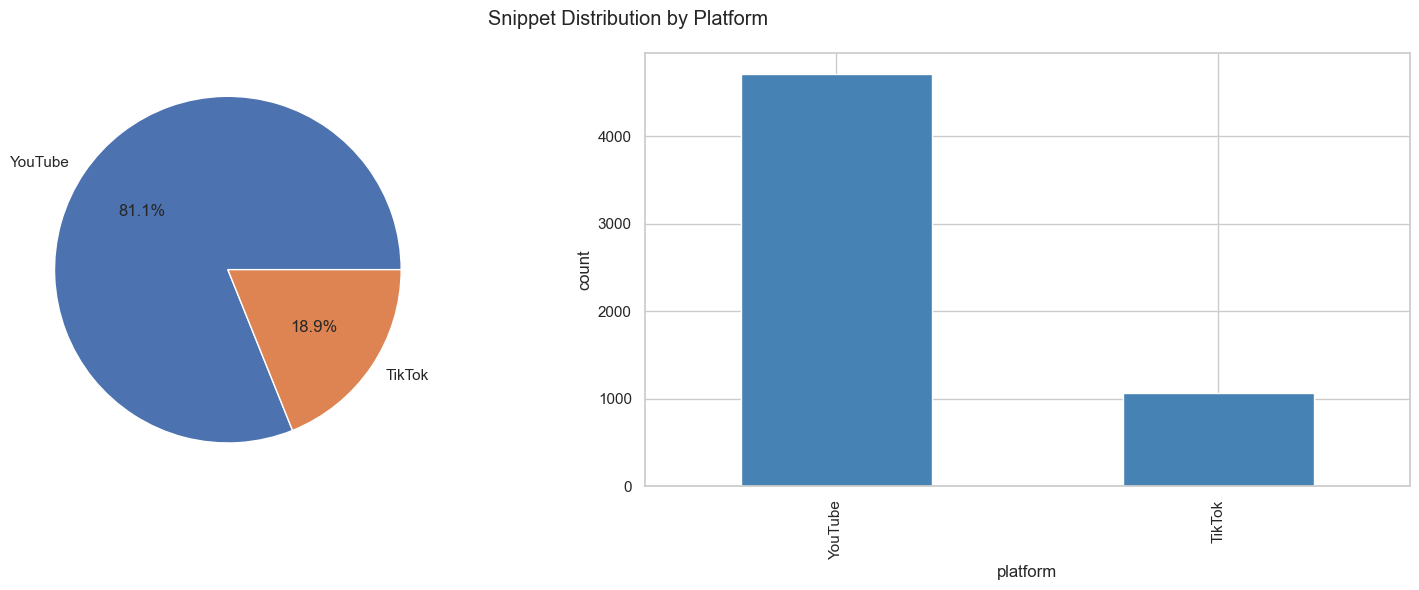

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plat = df["platform"].fillna("unknown")
plat.value_counts().plot.pie(ax=axes[0], autopct="%1.1f%%")
axes[0].set_ylabel("")
df[df["suitable_for_training"] == True]["platform"].fillna("unknown").value_counts().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_xlabel("platform")
axes[1].set_ylabel("count")
fig.suptitle("Snippet Distribution by Platform")
plt.tight_layout()
plt.show()


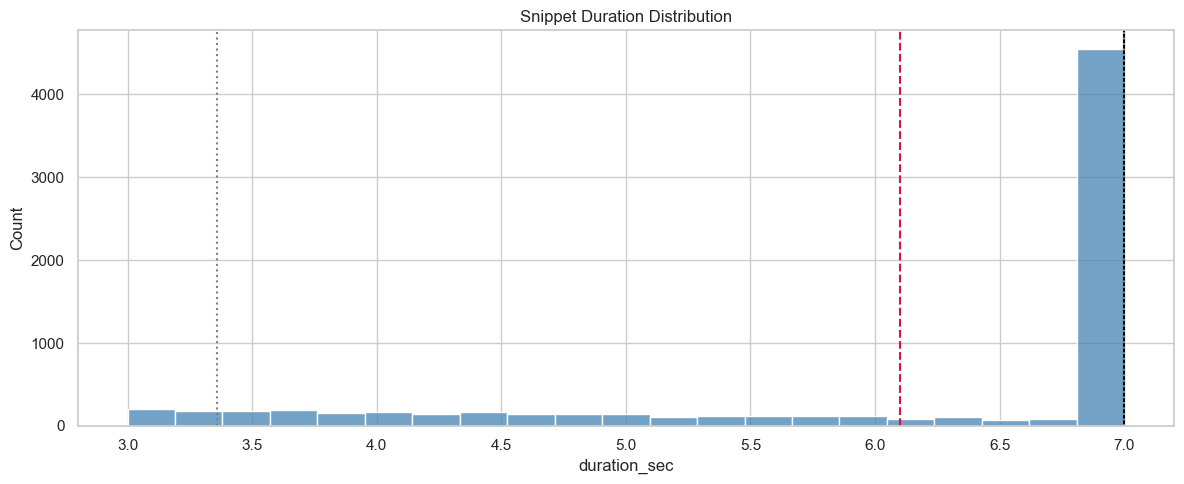

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
d = df["duration_sec"].dropna()
sns.histplot(d, kde=False, ax=ax, color="steelblue")
ax.axvline(d.mean(), color="crimson", linestyle="--", label=f"mean={d.mean():.2f}")
ax.axvline(d.median(), color="black", linestyle="-", label=f"median={d.median():.2f}")
ax.axvline(d.quantile(0.05), color="gray", linestyle=":", label=f"p5={d.quantile(0.05):.2f}")
ax.axvline(d.quantile(0.95), color="gray", linestyle=":", label=f"p95={d.quantile(0.95):.2f}")
ax.set_title("Snippet Duration Distribution")
plt.tight_layout()
plt.show()


## 2. Label Distribution


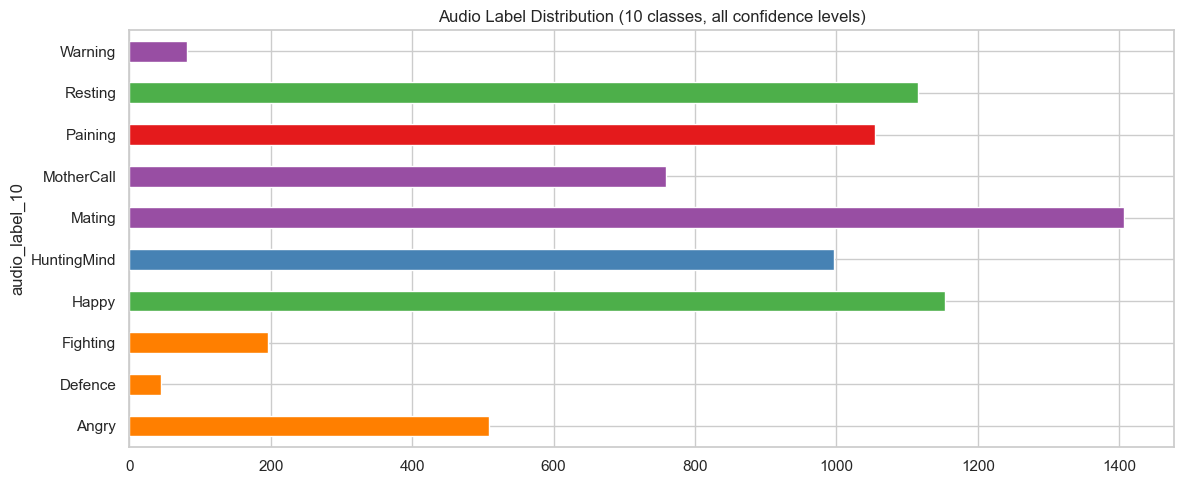

In [5]:
# 10-class: color bars by mapped 5-class parent
vc = df[df["audio_label_10"].notna()]["audio_label_10"].value_counts()
order10 = [
    "Angry", "Defence", "Fighting", "Happy", "HuntingMind",
    "Mating", "MotherCall", "Paining", "Resting", "Warning",
]
vc = vc.reindex([c for c in order10 if c in vc.index], fill_value=0)
colors = [COLORS_5.get(LABEL_10_TO_5.get(l, ""), "#bbbbbb") for l in vc.index]
fig, ax = plt.subplots(figsize=(12, 5))
vc.plot.barh(ax=ax, color=colors)
ax.set_title("Audio Label Distribution (10 classes, all confidence levels)")
plt.tight_layout()
plt.show()


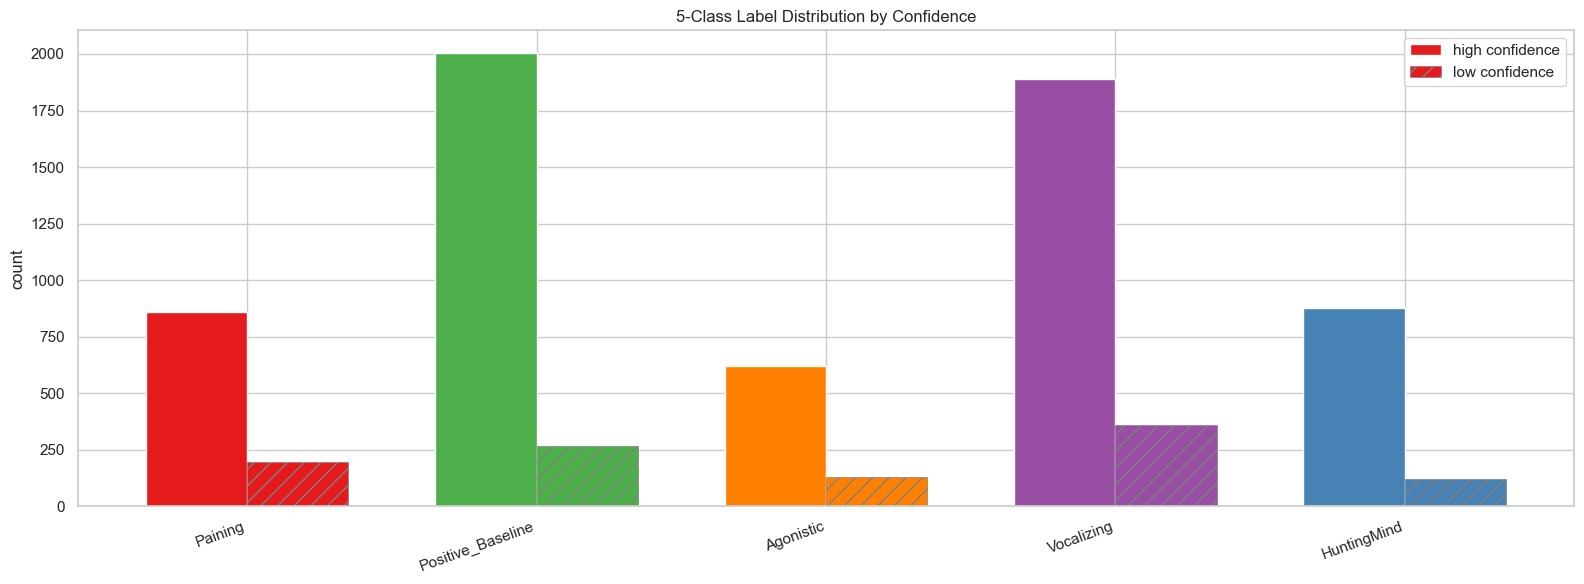

In [26]:
# 5-class: high vs low confidence counts per merged class
hi_mask = df["label_source"] == "audio_high_conf"
lab5 = df["audio_label_5"]
classes5 = ["Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"]
high_c = [int(((lab5 == c) & hi_mask).sum()) for c in classes5]
low_c = [int(((lab5 == c) & ~hi_mask & df["audio_label_10"].notna()).sum()) for c in classes5]
x = np.arange(len(classes5))
w = 0.35
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w / 2, high_c, w, label="high confidence", color=[COLORS_5[c] for c in classes5])
ax.bar(
    x + w / 2,
    low_c,
    w,
    label="low confidence",
    color=[COLORS_5[c] for c in classes5],
    hatch="//",
    edgecolor="gray",
    linewidth=0.5,
)
ax.set_xticks(x)
ax.set_xticklabels(classes5, rotation=20, ha="right")
ax.set_ylabel("count")
ax.legend()
ax.set_title("5-Class Label Distribution by Confidence")
plt.tight_layout()
plt.show()


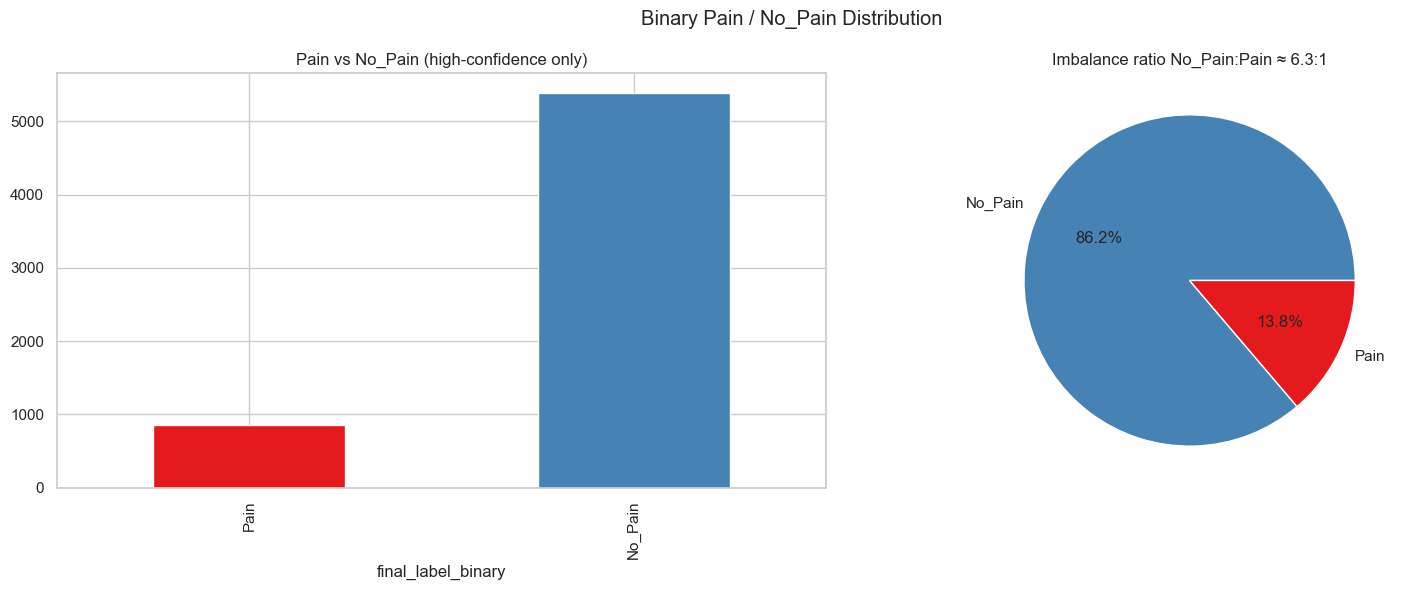

In [27]:
train_hi = df[df["label_source"] == "audio_high_conf"]
bc = train_hi["final_label_binary"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bc.reindex(["Pain", "No_Pain"]).fillna(0).plot.bar(ax=axes[0], color=[COLORS_BINARY.get(x, "#999") for x in ["Pain", "No_Pain"]])
axes[0].set_title("Pain vs No_Pain (high-confidence only)")
if bc.get("Pain", 0) > 0:
    ratio = bc.get("No_Pain", 0) / bc.get("Pain", 1)
else:
    ratio = float("nan")
axes[1].pie(bc, labels=bc.index, autopct="%1.1f%%", colors=[COLORS_BINARY.get(x, "#999") for x in bc.index])
axes[1].set_title(f"Imbalance ratio No_Pain:Pain ≈ {ratio:.1f}:1")
fig.suptitle("Binary Pain / No_Pain Distribution")
plt.tight_layout()
plt.show()


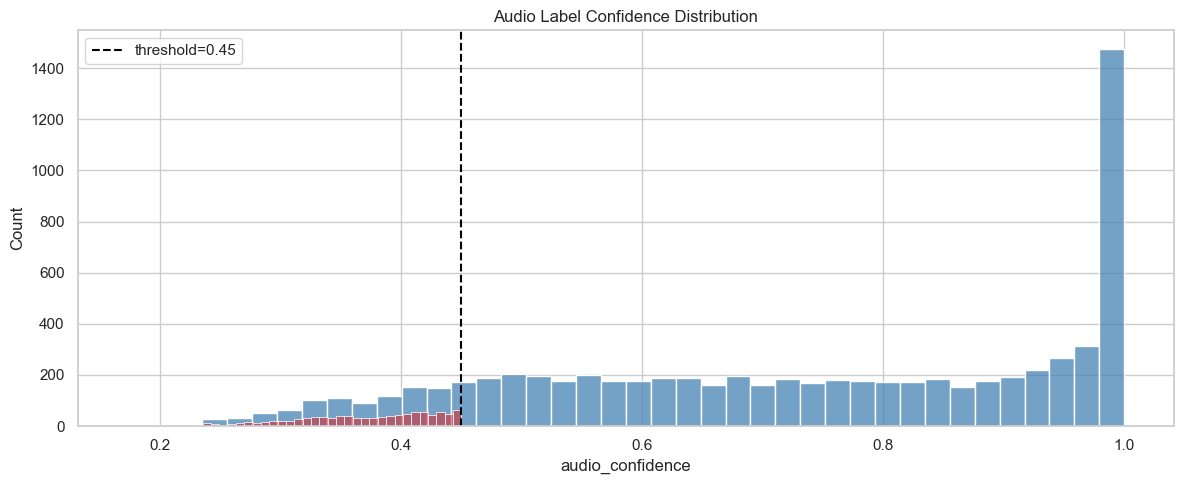

In [8]:
labeled = df[df["audio_label_10"].notna()]
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(labeled["audio_confidence"], bins=40, ax=ax, color="steelblue")
below = labeled[labeled["audio_confidence"] < CONF_THR]
above = labeled[labeled["audio_confidence"] >= CONF_THR]
if len(below):
    sns.histplot(below["audio_confidence"], bins=40, ax=ax, color="#e41a1c", alpha=0.5)
ax.axvline(CONF_THR, color="black", linestyle="--", label=f"threshold={CONF_THR}")
ax.set_title("Audio Label Confidence Distribution")
ax.legend()
plt.tight_layout()
plt.show()


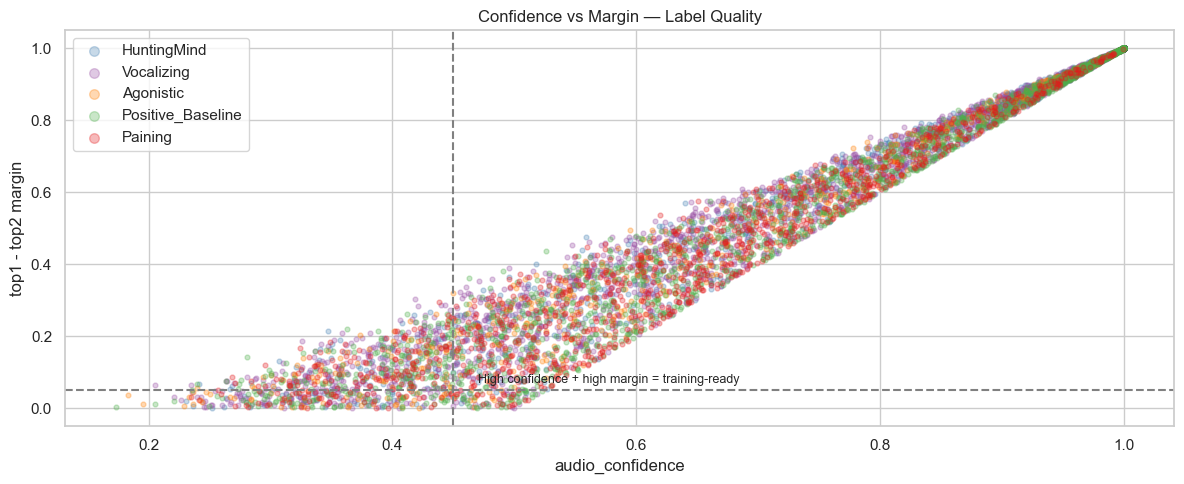

In [9]:
sub = df[df["audio_label_10"].notna()].copy()
sub["_color_lab"] = sub["final_label_5"].fillna(sub["audio_label_5"])
fig, ax = plt.subplots(figsize=(12, 5))
for lab in sub["_color_lab"].dropna().unique():
    m = sub["_color_lab"] == lab
    ax.scatter(
        sub.loc[m, "audio_confidence"],
        sub.loc[m, "_margin"],
        c=COLORS_5.get(lab, "#999"),
        label=lab,
        alpha=0.3,
        s=12,
    )
ax.axhline(MARGIN_THR, color="gray", linestyle="--")
ax.axvline(CONF_THR, color="gray", linestyle="--")
ax.text(
    CONF_THR + 0.02,
    MARGIN_THR + 0.02,
    "High confidence + high margin = training-ready",
    fontsize=9,
)
ax.set_xlabel("audio_confidence")
ax.set_ylabel("top1 - top2 margin")
ax.legend(markerscale=2)
ax.set_title("Confidence vs Margin — Label Quality")
plt.tight_layout()
plt.show()


## 3. GPT Description Analysis


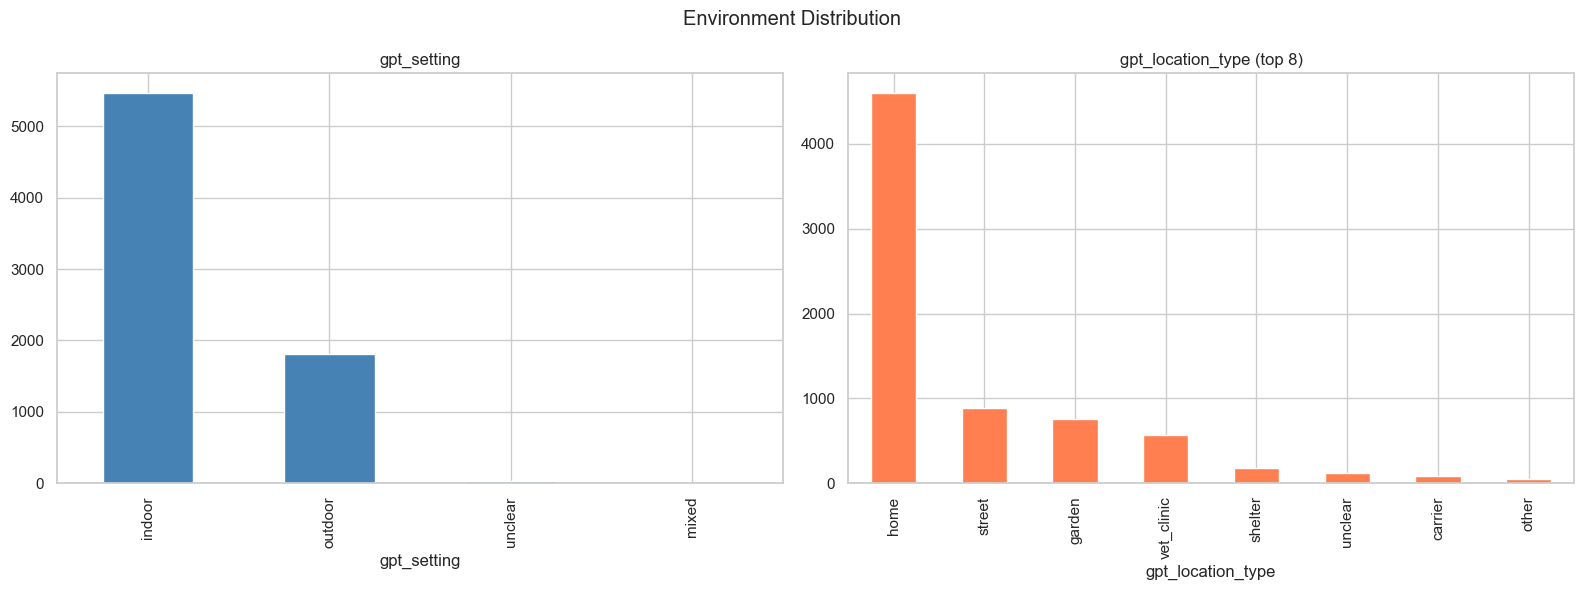

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["gpt_setting"].fillna("unknown").value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("gpt_setting")
df["gpt_location_type"].fillna("unknown").value_counts().head(8).plot.bar(ax=axes[1], color="coral")
axes[1].set_title("gpt_location_type (top 8)")
fig.suptitle("Environment Distribution")
plt.tight_layout()
plt.show()


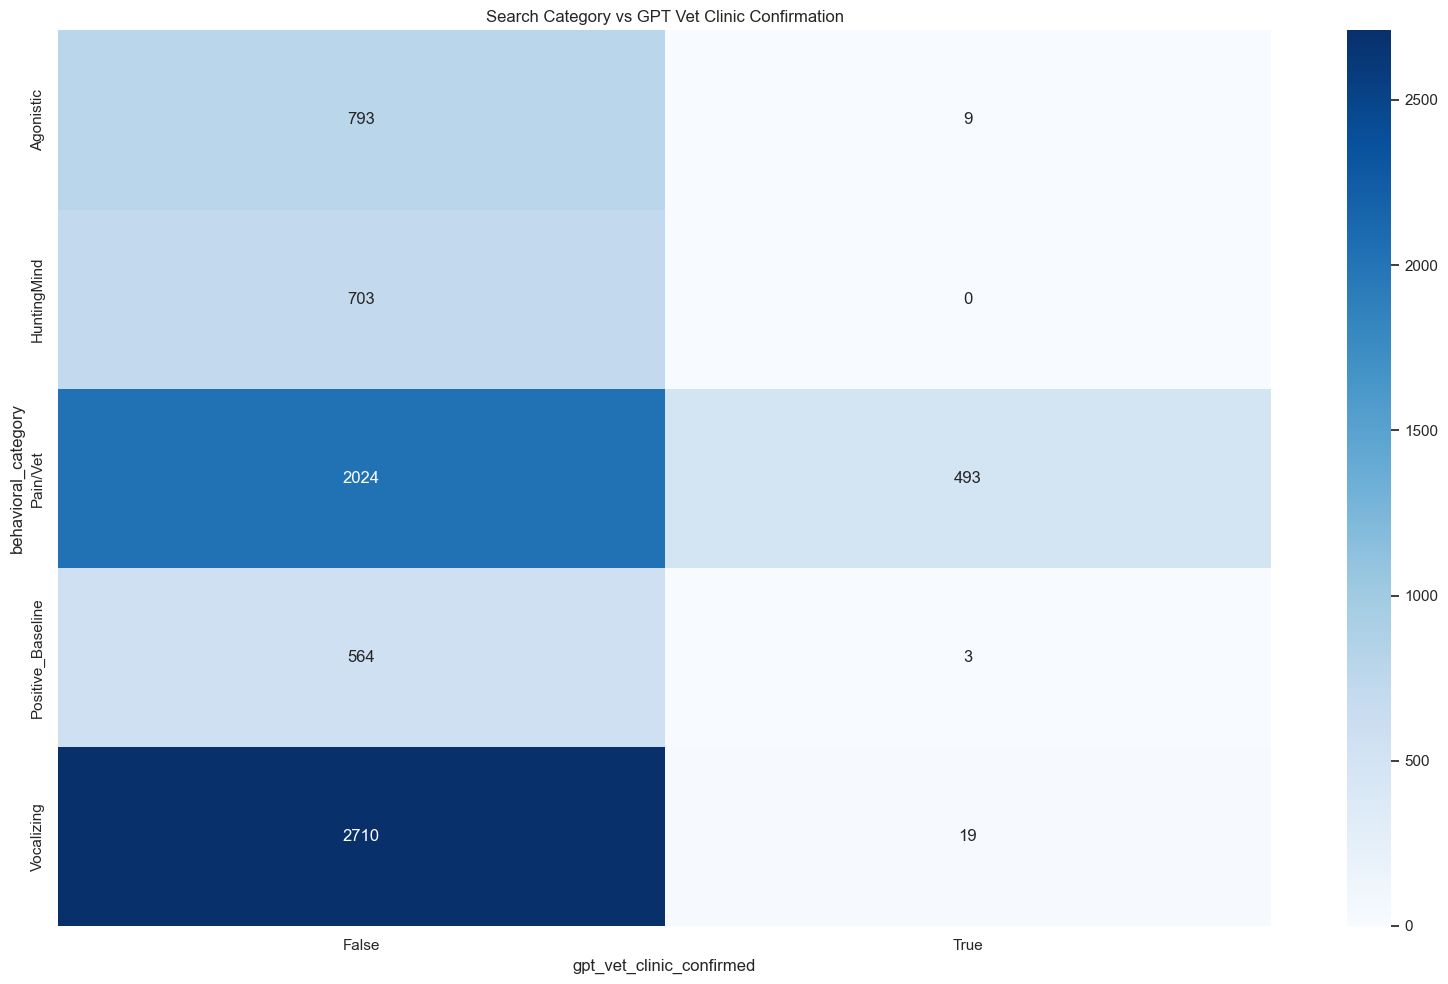

In [11]:
ct = pd.crosstab(df["behavioral_category"], df["gpt_vet_clinic_confirmed"].fillna("NA"))
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Search Category vs GPT Vet Clinic Confirmation")
plt.tight_layout()
plt.show()


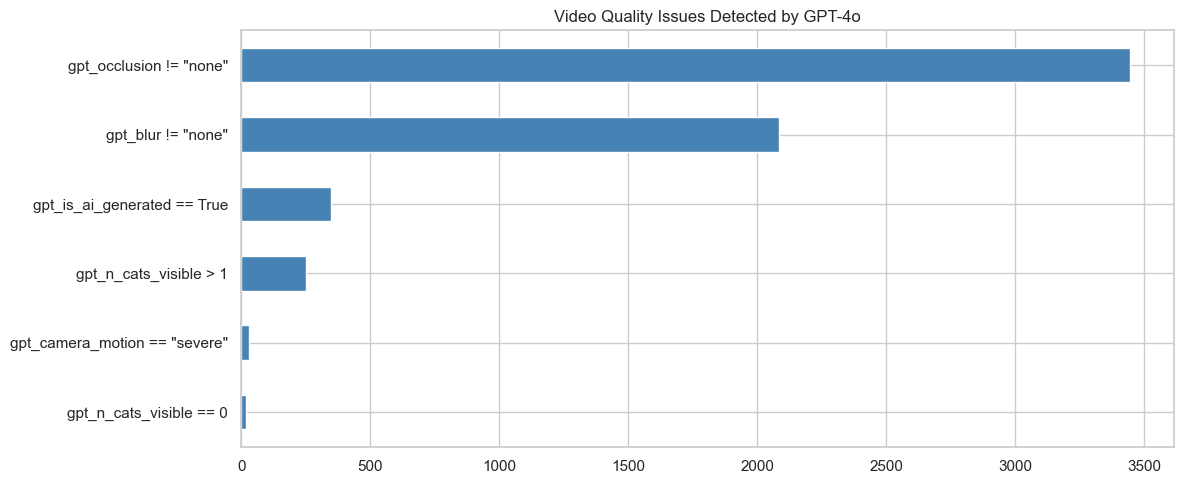

In [12]:
flags = {
    'gpt_blur != "none"': (df["gpt_blur"].fillna("none") != "none").sum(),
    'gpt_occlusion != "none"': (df["gpt_occlusion"].fillna("none") != "none").sum(),
    'gpt_camera_motion == "severe"': (df["gpt_camera_motion"].fillna("") == "severe").sum(),
    "gpt_is_ai_generated == True": (df["gpt_is_ai_generated"] == True).sum(),  # noqa: E712
    "gpt_n_cats_visible == 0": (df["gpt_n_cats_visible"].fillna(-1) == 0).sum(),
    "gpt_n_cats_visible > 1": (df["gpt_n_cats_visible"].fillna(0) > 1).sum(),
}
fig, ax = plt.subplots(figsize=(12, 5))
pd.Series(flags).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("Video Quality Issues Detected by GPT-4o")
plt.tight_layout()
plt.show()


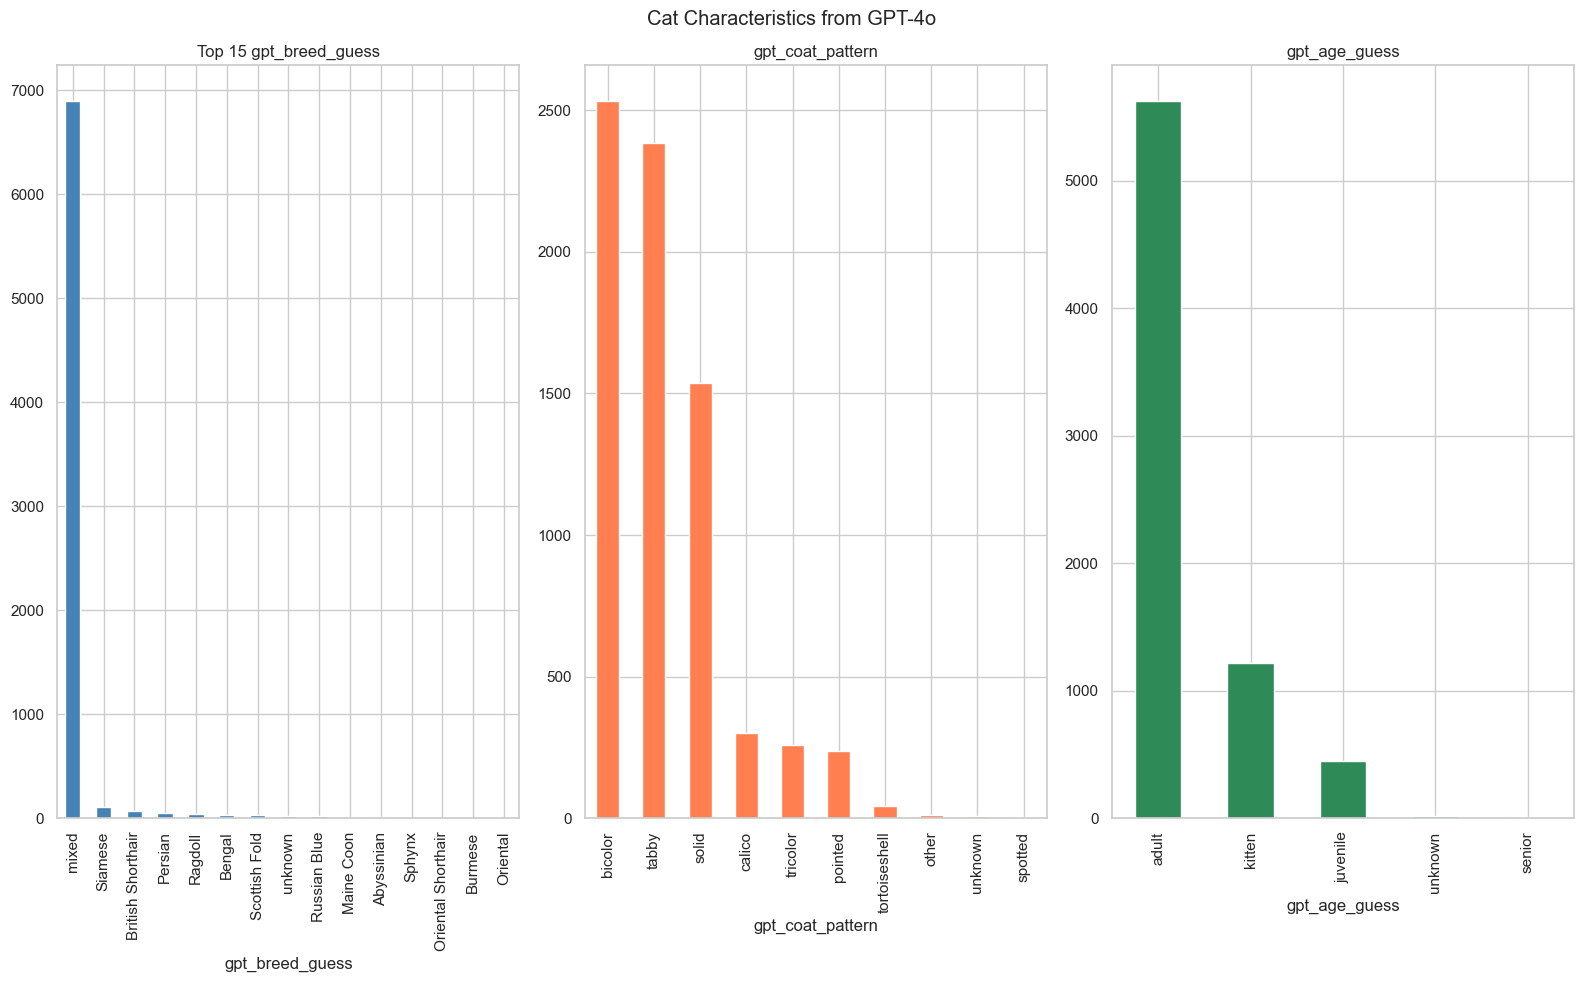

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10))
df["gpt_breed_guess"].fillna("unknown").value_counts().head(15).plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 gpt_breed_guess")
df["gpt_coat_pattern"].fillna("unknown").value_counts().plot.bar(ax=axes[1], color="coral")
axes[1].set_title("gpt_coat_pattern")
df["gpt_age_guess"].fillna("unknown").value_counts().plot.bar(ax=axes[2], color="seagreen")
axes[2].set_title("gpt_age_guess")
fig.suptitle("Cat Characteristics from GPT-4o")
plt.tight_layout()
plt.show()


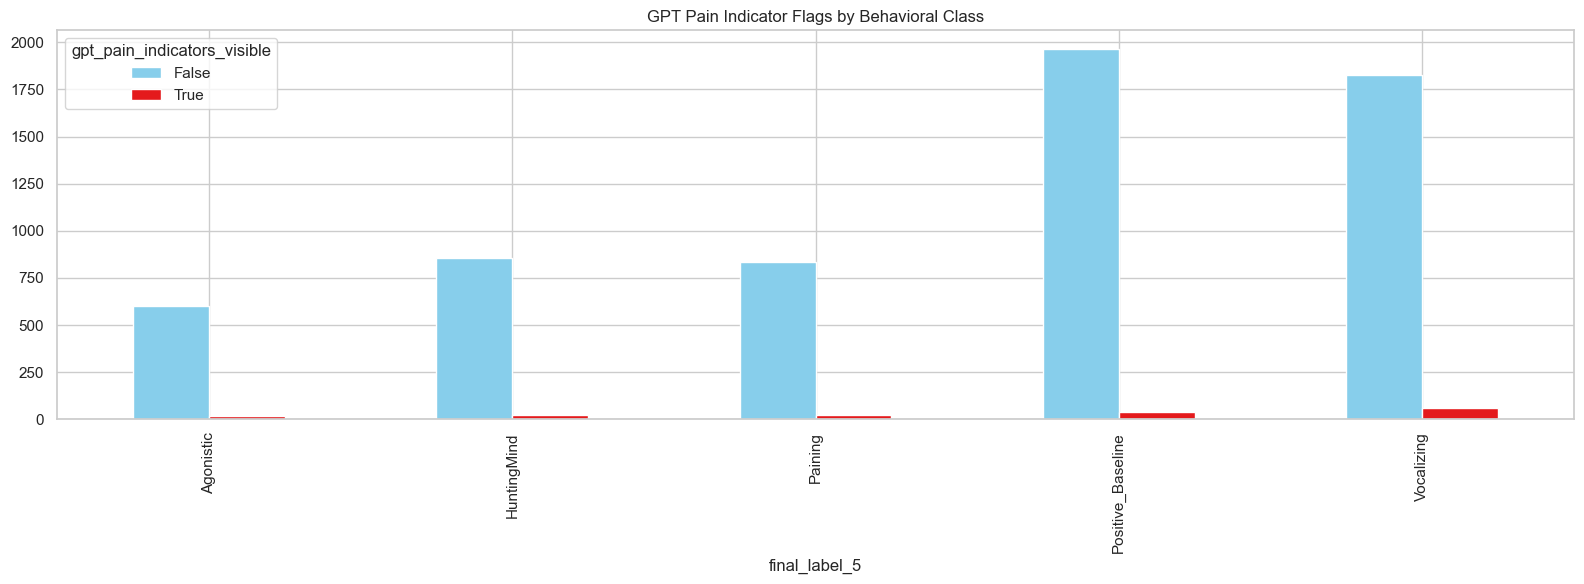

In [14]:
sub = df[df["final_label_5"].notna()]
ct = pd.crosstab(sub["final_label_5"], sub["gpt_pain_indicators_visible"].fillna(False))
fig, ax = plt.subplots(figsize=(16, 6))
ct.plot.bar(ax=ax, color=["#87ceeb", "#e41a1c"])
ax.set_title("GPT Pain Indicator Flags by Behavioral Class")
ax.legend(title="gpt_pain_indicators_visible")
plt.tight_layout()
plt.show()


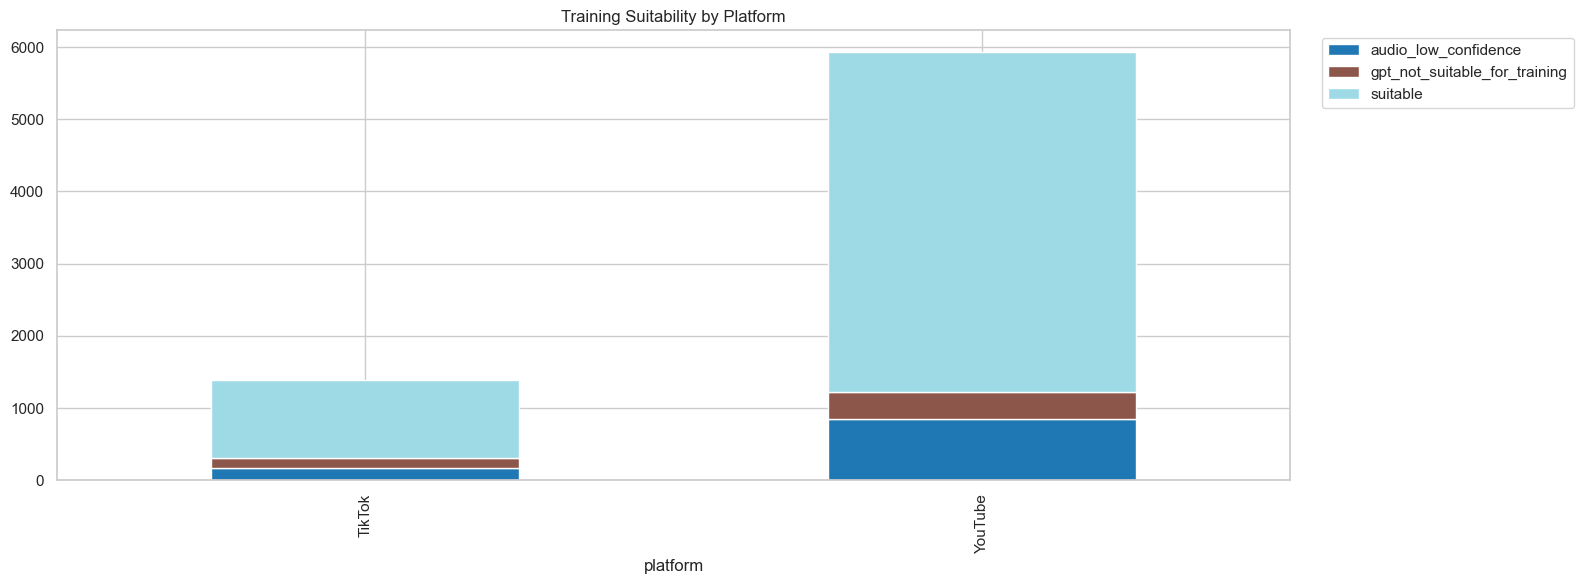

In [15]:
reason = np.where(df["suitable_for_training"], "suitable", df["unsuitable_reason"].fillna("unknown"))
stack = pd.crosstab(df["platform"].fillna("unknown"), reason)
fig, ax = plt.subplots(figsize=(16, 6))
stack.plot.bar(stacked=True, ax=ax, colormap="tab20")
ax.set_title("Training Suitability by Platform")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 4. Cat Identity Analysis


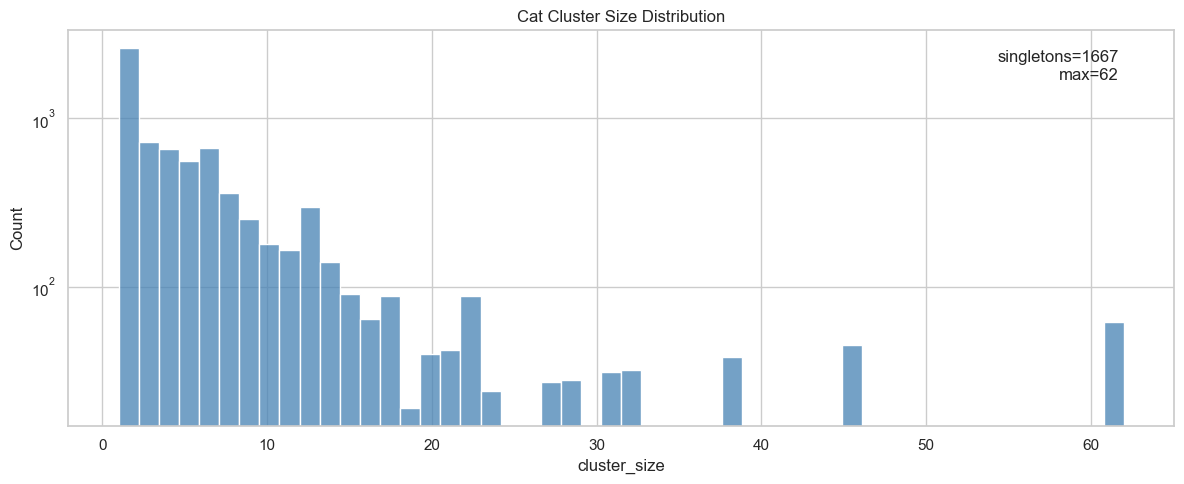

In [16]:
cs = df["cluster_size"].dropna()
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(cs, bins=50, ax=ax, color="steelblue")
ax.set_yscale("log")
ax.set_title("Cat Cluster Size Distribution")
singletons = int((cs == 1).sum())
ax.text(0.95, 0.95, f"singletons={singletons}\nmax={int(cs.max())}", transform=ax.transAxes, ha="right", va="top")
plt.tight_layout()
plt.show()


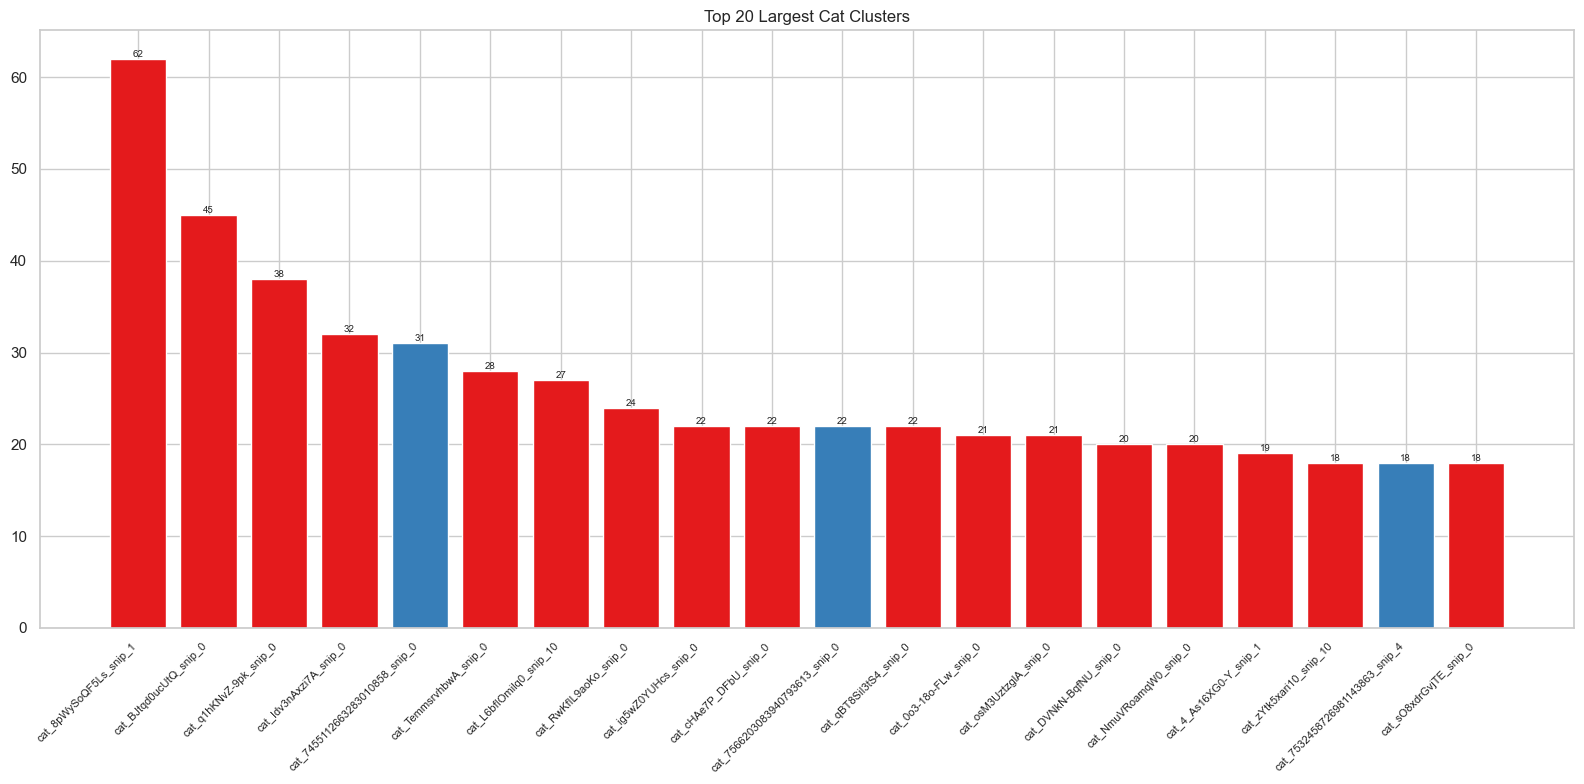

In [17]:
top = df.groupby("cat_id")["cluster_size"].first().sort_values(ascending=False).head(20)
plat_maj = []
for cid in top.index:
    sub = df[df["cat_id"] == cid]
    plat_maj.append(sub["platform"].mode().iloc[0] if len(sub) else "unknown")
fig, ax = plt.subplots(figsize=(16, 8))
PLAT_COL = {"YouTube": "#e41a1c", "TikTok": "#377eb8", "DailyMotion": "#4daf4a", "unknown": "#999999"}
colors = [PLAT_COL.get(p, "#999") for p in plat_maj]
bars = ax.bar(range(len(top)), top.values, color=colors)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=45, ha="right", fontsize=8)
for i, b in enumerate(bars):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(int(top.values[i])), ha="center", va="bottom", fontsize=7)
ax.set_title("Top 20 Largest Cat Clusters")
plt.tight_layout()
plt.show()


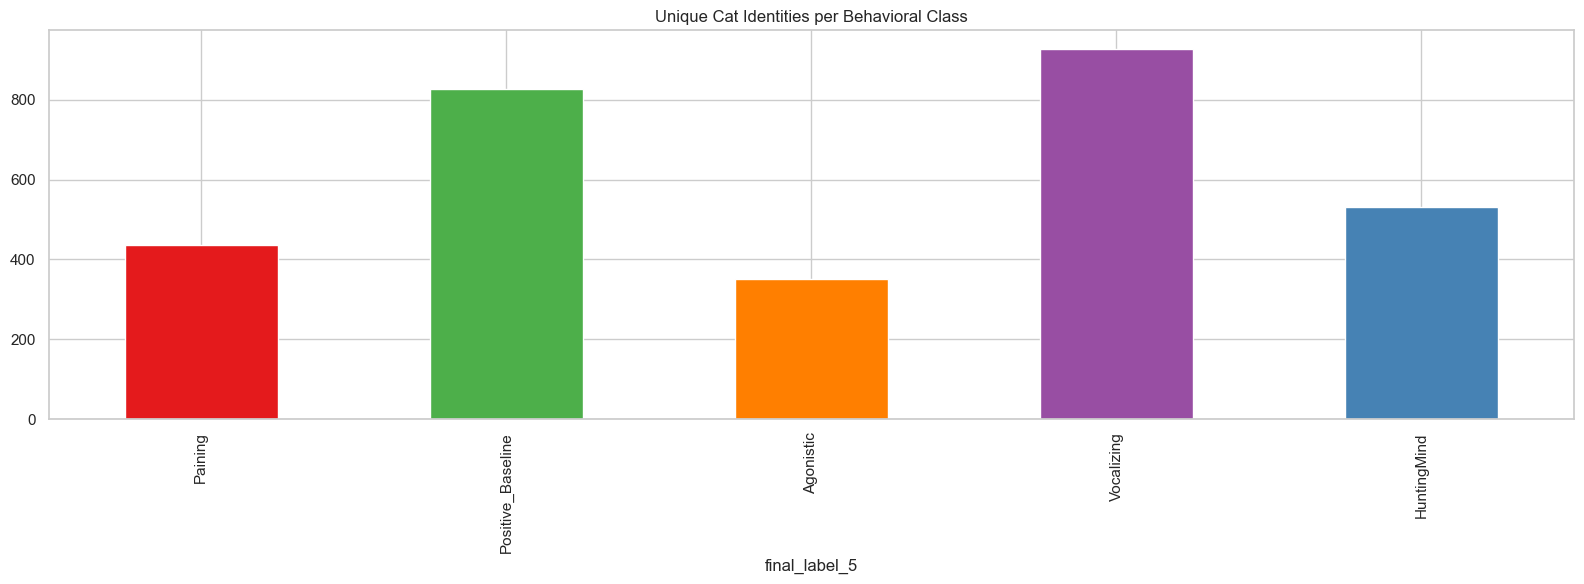

In [18]:
tr = df[df["suitable_for_training"] == True]  # noqa: E712
uc = tr.groupby("final_label_5")["cat_id"].nunique()
_ord = [c for c in COLORS_5 if c in uc.index]
uc = uc.reindex(_ord).dropna()
fig, ax = plt.subplots(figsize=(16, 6))
uc.plot.bar(ax=ax, color=[COLORS_5[i] for i in uc.index])
ax.set_title("Unique Cat Identities per Behavioral Class")
plt.tight_layout()
plt.show()


## 5. Training Dataset Summary


In [19]:
tr = df[df["suitable_for_training"] == True]  # noqa: E712
print(f"Training-ready snippets:  {len(tr)}")
print(f"Unique cat_ids:           {tr['cat_id'].nunique()}  (used as CV groups)")
print(f"Unique video_ids:         {tr['video_id'].nunique()}")
print(f"Approx. hours:            {tr['duration_sec'].sum()/3600:.1f}h")
print("")
rows = []
for lab, grp in tr.groupby("final_label_5"):
    rows.append(
        {
            "class": lab,
            "count": len(grp),
            "pct": 100 * len(grp) / max(1, len(tr)),
            "uniq_cats": grp["cat_id"].nunique(),
            "mean_conf": grp["audio_confidence"].mean(),
        }
    )
tab = pd.DataFrame(rows).sort_values("count", ascending=False)
print("Class | Count | % | Unique cats | Mean confidence")
print(tab.to_string(index=False))


Training-ready snippets:  5786
Unique cat_ids:           2198  (used as CV groups)
Unique video_ids:         2262
Approx. hours:            9.9h

Class | Count | % | Unique cats | Mean confidence
            class  count       pct  uniq_cats  mean_conf
Positive_Baseline   1825 31.541652        827   0.835932
       Vocalizing   1785 30.850328        927   0.783721
      HuntingMind    839 14.500518        531   0.819549
          Paining    783 13.532665        436   0.684603
        Agonistic    554  9.574836        352   0.780466


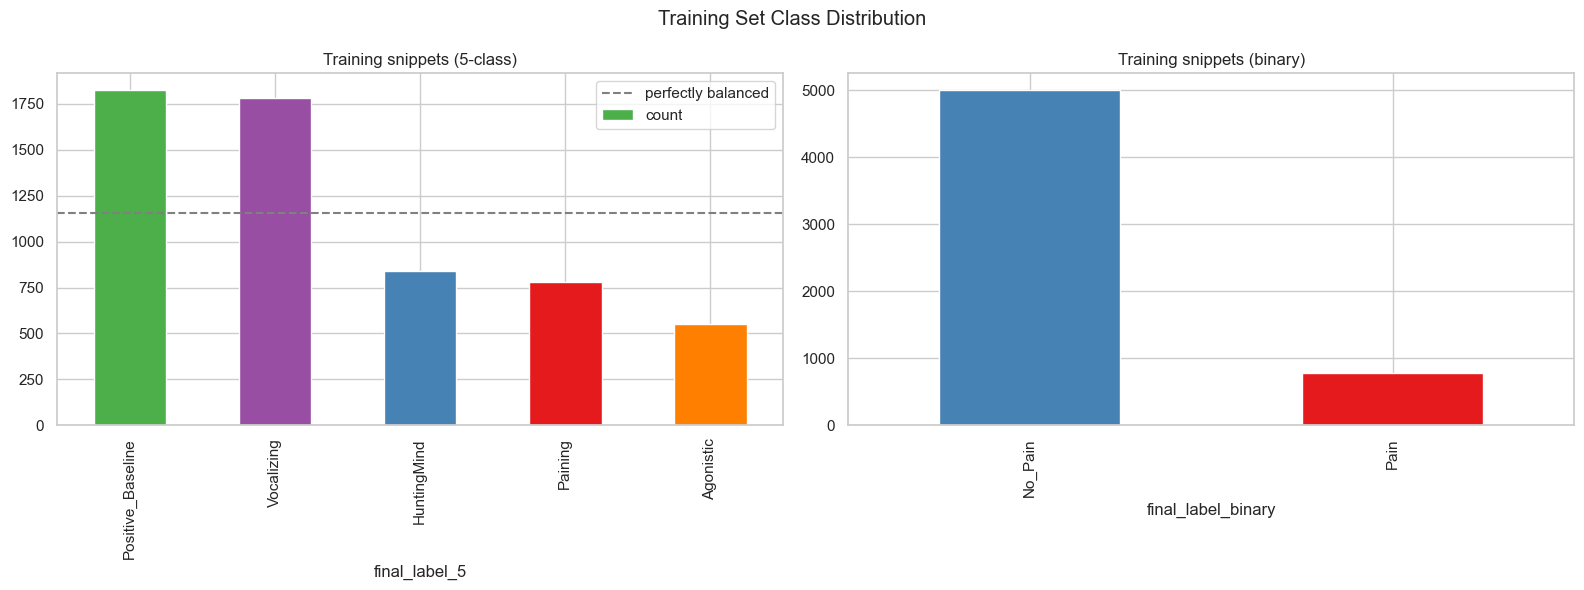

In [20]:
tr = df[df["suitable_for_training"] == True]  # noqa: E712
vc5 = tr["final_label_5"].value_counts()
vcb = tr["final_label_binary"].value_counts()
bal = len(tr) / max(1, len(vc5))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vc5.plot.bar(ax=axes[0], color=[COLORS_5.get(i, "#999") for i in vc5.index])
axes[0].axhline(bal, color="gray", linestyle="--", label="perfectly balanced")
axes[0].legend()
axes[0].set_title("Training snippets (5-class)")
vcb.plot.bar(ax=axes[1], color=[COLORS_BINARY.get(i, "#999") for i in vcb.index])
axes[1].set_title("Training snippets (binary)")
fig.suptitle("Training Set Class Distribution")
plt.tight_layout()
plt.show()


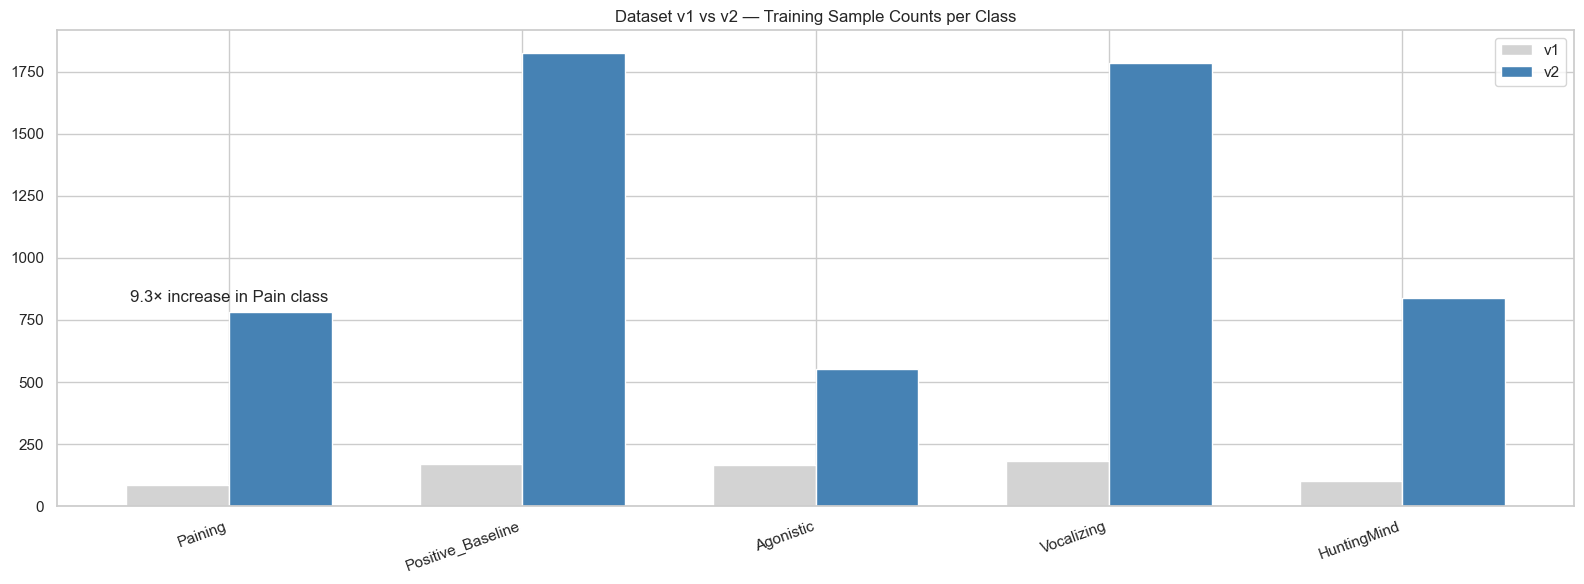

In [21]:
# Dataset v1 numbers from thesis_report/01_dataset_v1.txt
V1_TOTAL = 715
V1_PAINING = 84
V1_POSITIVE = 172
V1_AGONISTIC = 164
V1_VOCALIZING = 184
V1_HUNTINGMIND = 103

tr = df[df["suitable_for_training"] == True]  # noqa: E712
v2 = tr["final_label_5"].value_counts()
labels5 = ["Paining", "Positive_Baseline", "Agonistic", "Vocalizing", "HuntingMind"]
v1_map = {
    "Paining": V1_PAINING,
    "Positive_Baseline": V1_POSITIVE,
    "Agonistic": V1_AGONISTIC,
    "Vocalizing": V1_VOCALIZING,
    "HuntingMind": V1_HUNTINGMIND,
}
x = np.arange(len(labels5))
w = 0.35
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w / 2, [v1_map[l] for l in labels5], w, label="v1", color="lightgray")
ax.bar(x + w / 2, [int(v2.get(l, 0)) for l in labels5], w, label="v2", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels5, rotation=20, ha="right")
ax.legend()
if v1_map["Paining"]:
    ax.text(
        0,
        max(v2.get("Paining", 0), v1_map["Paining"]) * 1.05,
        f"{v2.get('Paining',0)/ max(1,v1_map['Paining']):.1f}× increase in Pain class",
        ha="center",
    )
ax.set_title("Dataset v1 vs v2 — Training Sample Counts per Class")
plt.tight_layout()
plt.show()


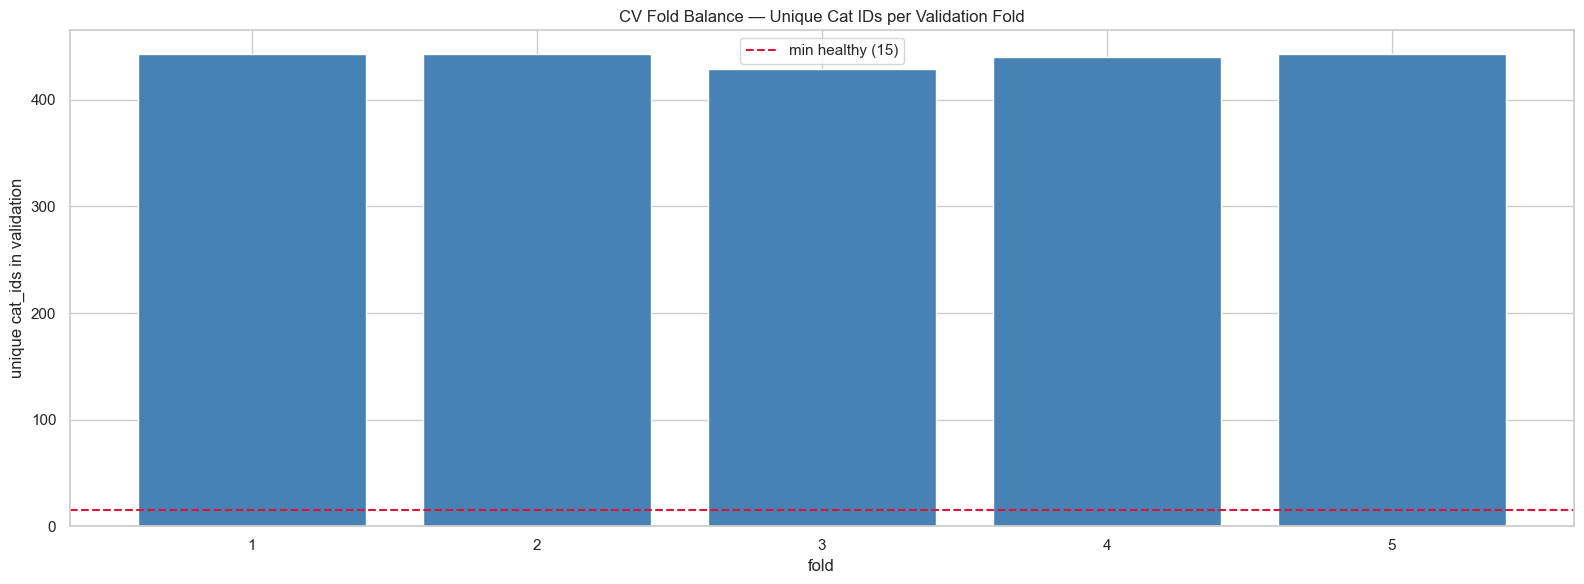

In [22]:
from sklearn.model_selection import StratifiedGroupKFold

tr = df[df["suitable_for_training"] == True].dropna(subset=["final_label_5", "cat_id"])  # noqa: E712
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
X = np.zeros(len(tr))
y = tr["final_label_5"].astype(str).values
groups = tr["cat_id"].astype(str).values
fold_cats = []
for _, val_idx in sgkf.split(X, y, groups):
    fold_cats.append(tr.iloc[val_idx]["cat_id"].nunique())
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(range(1, 6), fold_cats, color="steelblue")
ax.axhline(15, color="crimson", linestyle="--", label="min healthy (15)")
ax.set_xlabel("fold")
ax.set_ylabel("unique cat_ids in validation")
ax.legend()
ax.set_title("CV Fold Balance — Unique Cat IDs per Validation Fold")
plt.tight_layout()
plt.show()


## 6. Audio Label vs GPT Description Correlation


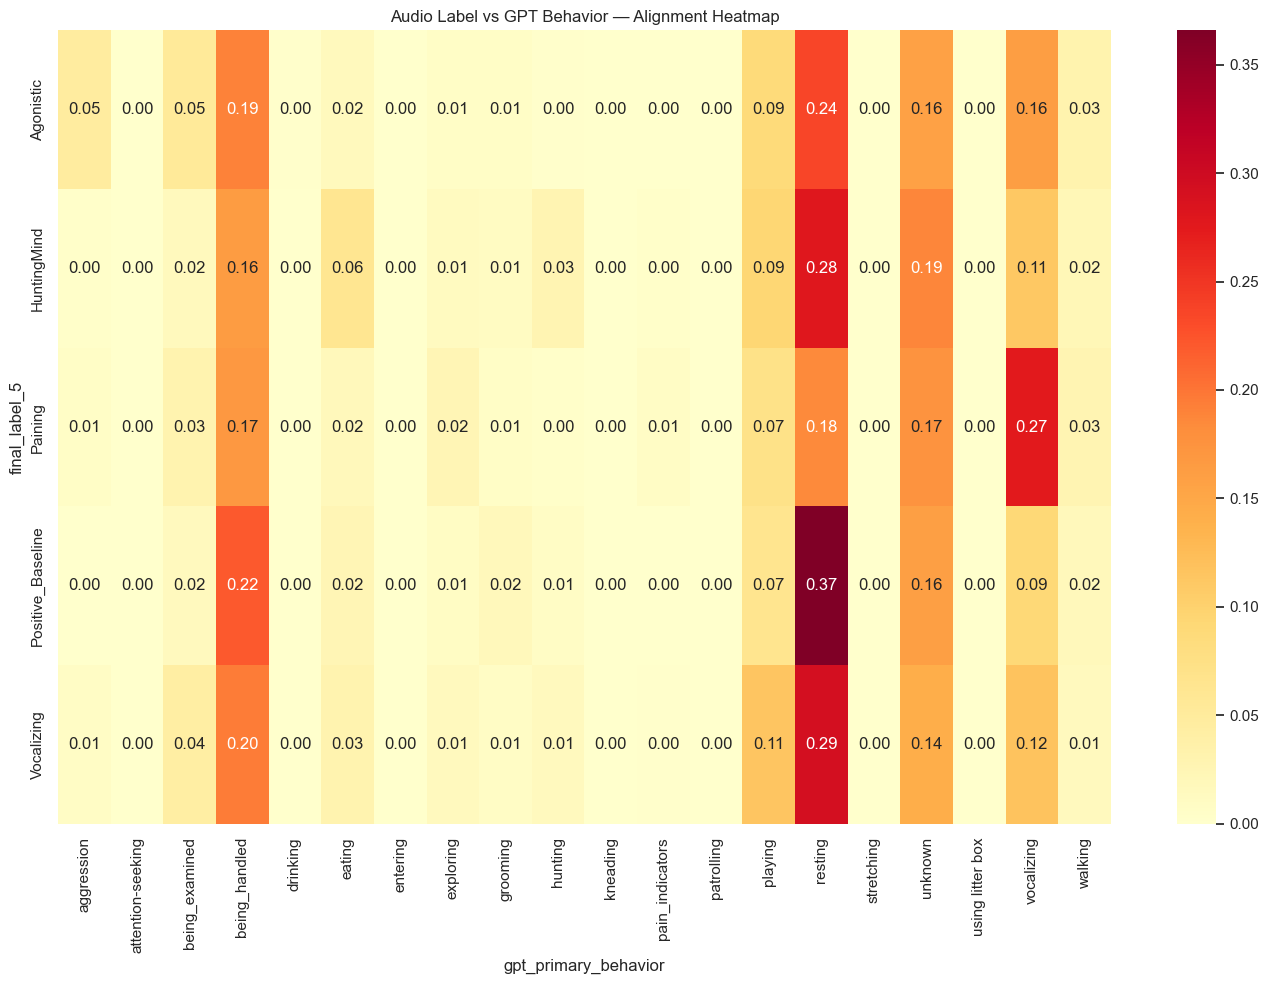

High diagonal = audio and visual labels agree


In [23]:
sub = df[df["final_label_5"].notna()].copy()
ct = pd.crosstab(sub["final_label_5"], sub["gpt_primary_behavior"].fillna("unknown"))
ct_n = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(ct_n, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Audio Label vs GPT Behavior — Alignment Heatmap")
plt.tight_layout()
plt.show()
print("High diagonal = audio and visual labels agree")


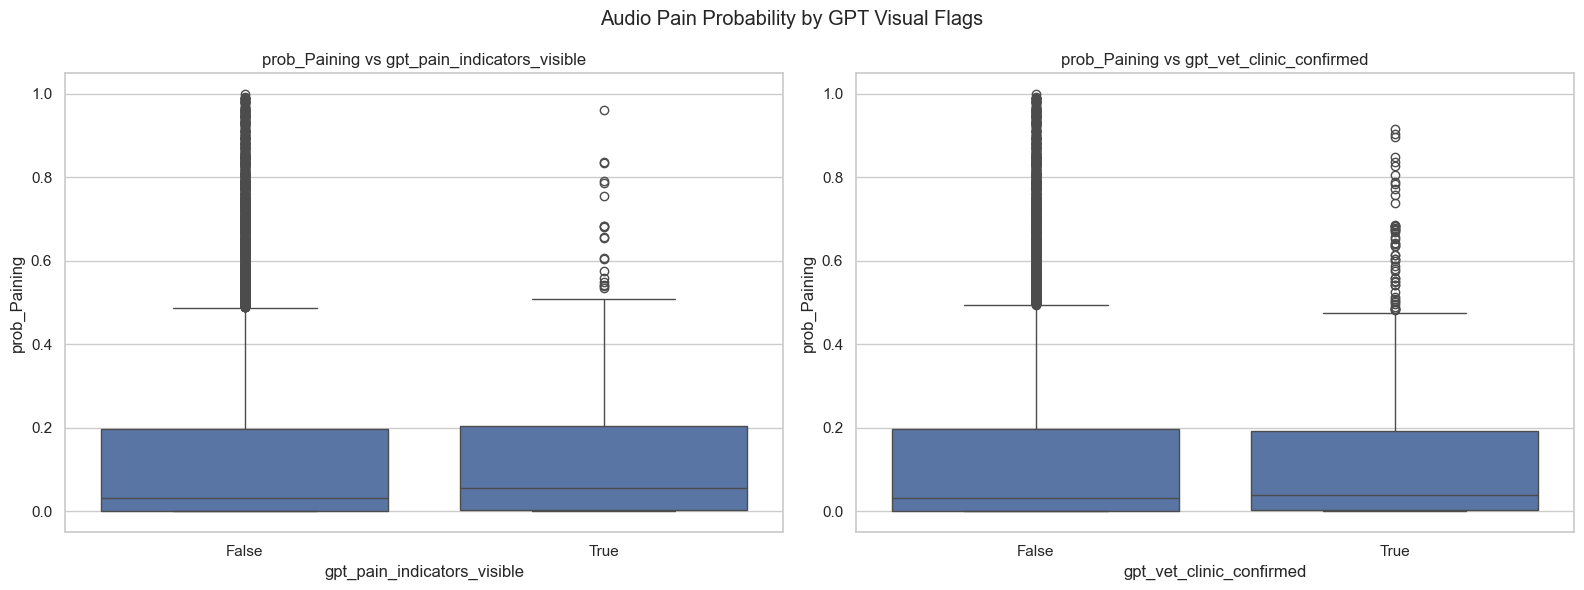

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(
    data=df,
    x="gpt_pain_indicators_visible",
    y="prob_Paining",
    ax=axes[0],
)
axes[0].set_title("prob_Paining vs gpt_pain_indicators_visible")
sns.boxplot(
    data=df,
    x="gpt_vet_clinic_confirmed",
    y="prob_Paining",
    ax=axes[1],
)
axes[1].set_title("prob_Paining vs gpt_vet_clinic_confirmed")
fig.suptitle("Audio Pain Probability by GPT Visual Flags")
plt.tight_layout()
plt.show()


## Summary


In [25]:
tr = df[df["suitable_for_training"] == True]  # noqa: E712
lab_any = df["audio_label_10"].notna()
hi = df["label_source"] == "audio_high_conf"
vc5 = tr["final_label_5"].value_counts()
most = vc5.idxmax()
least = vc5.idxmin()
ratio = vc5.min() / max(1, vc5.max())
v1_pain = 84
print("DATASET V2 SUMMARY")
print("══════════════════════════════════════════════")
print(f"Total snippets collected:     {len(df)}")
print(f"After quality filtering:      {len(tr)} (suitable_for_training=True)")
print(f"Reduction from filtering:     {100*(1-len(tr)/max(1,len(df))):.1f}%")
print("")
print("Label quality:")
print(f"  High-confidence labels:     {int(hi.sum())} ({100*hi.mean():.1f}%)")
print(f"  Mean confidence:            {df.loc[lab_any, 'audio_confidence'].mean():.3f}")
print(f"  Mean margin (top1-top2):    {df.loc[lab_any, '_margin'].mean():.3f}")
print("")
print("Class balance (training set):")
print(f"  Most common class:    {most} ({vc5[most]}, {100*vc5[most]/len(tr):.1f}%)")
print(f"  Least common class:   {least} ({vc5[least]}, {100*vc5[least]/len(tr):.1f}%)")
print(f"  Imbalance ratio:      1:{1/max(1e-9, ratio):.1f} (least:most)")
print(f"  Pain class count:     {vc5.get('Paining',0)}  (↑ {vc5.get('Paining',0)/ max(1,v1_pain):.1f}× vs dataset v1)")
print("")
print("Cat identity:")
print(f"  Unique cat_ids:       {tr['cat_id'].nunique()}")
print(f"  Mean snippets/cat:    {len(tr)/ max(1, tr['cat_id'].nunique()):.1f}")
print(f"  Max snippets/cat:     {tr.groupby('cat_id').size().max()}")
print("")
print("Estimated training improvement over v1:")
print(f"  Pain class: {v1_pain} → {int(vc5.get('Paining',0))} clips ({vc5.get('Paining',0)/ max(1,v1_pain):.1f}× increase)")
print(f"  Total:      715 → {len(tr)} clips ({len(tr)/715:.1f}× increase)")
print("══════════════════════════════════════════════")


DATASET V2 SUMMARY
══════════════════════════════════════════════
Total snippets collected:     7318
After quality filtering:      5786 (suitable_for_training=True)
Reduction from filtering:     20.9%

Label quality:
  High-confidence labels:     6247 (85.4%)
  Mean confidence:            0.732
  Mean margin (top1-top2):    0.578

Class balance (training set):
  Most common class:    Positive_Baseline (1825, 31.5%)
  Least common class:   Agonistic (554, 9.6%)
  Imbalance ratio:      1:3.3 (least:most)
  Pain class count:     783  (↑ 9.3× vs dataset v1)

Cat identity:
  Unique cat_ids:       2198
  Mean snippets/cat:    2.6
  Max snippets/cat:     59

Estimated training improvement over v1:
  Pain class: 84 → 783 clips (9.3× increase)
  Total:      715 → 5786 clips (8.1× increase)
══════════════════════════════════════════════
